# Machine Learning Technologies — In-Class Lab Assessment
## Group A — Dry Bean Dataset

**Student Name:**  ARIEL CASSIANO NUNES
**Student ID:**  G00418763

> Replace your random seed with your student ID number (remove leading G and zeros).
> Feel free to add extra code blocks as needed

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)

In [2]:
SEED = 418763
df = pd.read_csv("drybean.csv")

---
## Task 1 — Exploratory Data Analysis

In [3]:
# 1.1 Display shape, first rows, and basic statistics
print("Shape:", df.shape)
print("\nBasic Statistics:")
display(df.describe())
df.head()

Shape: (13611, 17)

Basic Statistics:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [5]:
# 1.2 Check for missing values
print('NaN per column:\n', df.isnull().sum())

NaN per column:
 Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


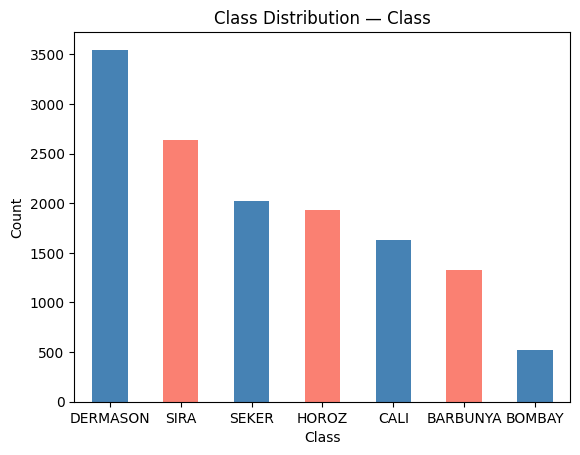

In [6]:
# 1.3 Class distribution plot
df["Class"].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.title(f'Class Distribution — {df["Class"].name}')
plt.show()


/tmp/ipykernel_68092/127425758.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(classes))


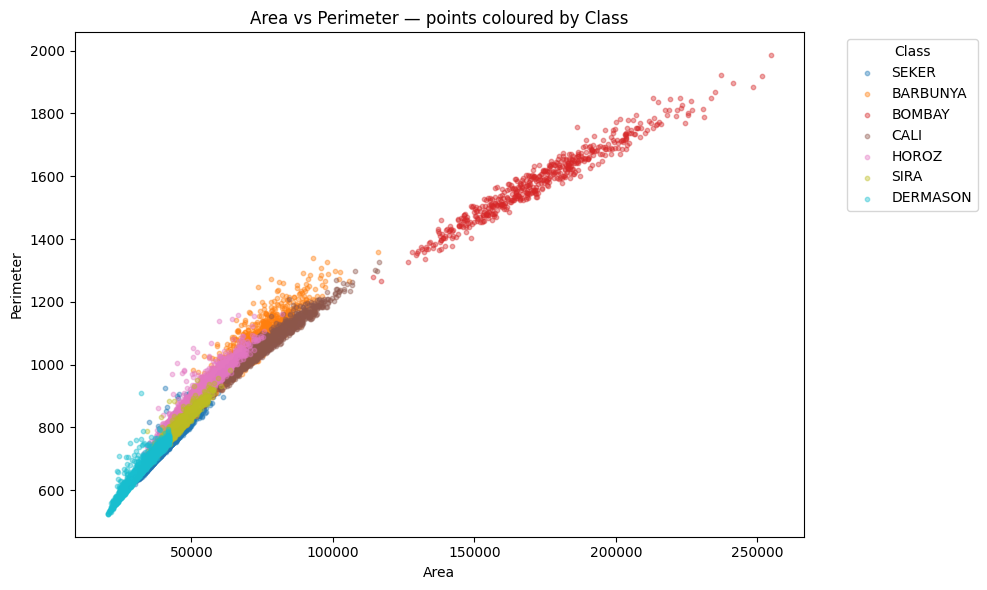

In [7]:
# 1.4 Scatter plot of two features coloured by class
fig, ax = plt.subplots(figsize=(10, 6))
classes = df['Class'].unique()
cmap = plt.cm.get_cmap('tab10', len(classes))

for i, cls in enumerate(classes):
    mask = df['Class'] == cls
    ax.scatter(df.loc[mask, 'Area'], df.loc[mask, 'Perimeter'],
               alpha=0.4, label=cls, color=cmap(i), s=10)

ax.set_xlabel('Area')
ax.set_ylabel('Perimeter')
ax.set_title('Area vs Perimeter — points coloured by Class')
ax.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Comment: The classes show partial separation — BOMBAY is clearly isolated (large Area & Perimeter),
# but DERMASON, SIRA, BARBUNYA, CALI, HOROZ, and SEKER overlap considerably in this feature pair,
# suggesting the pair is not sufficient alone for clean linear separation.

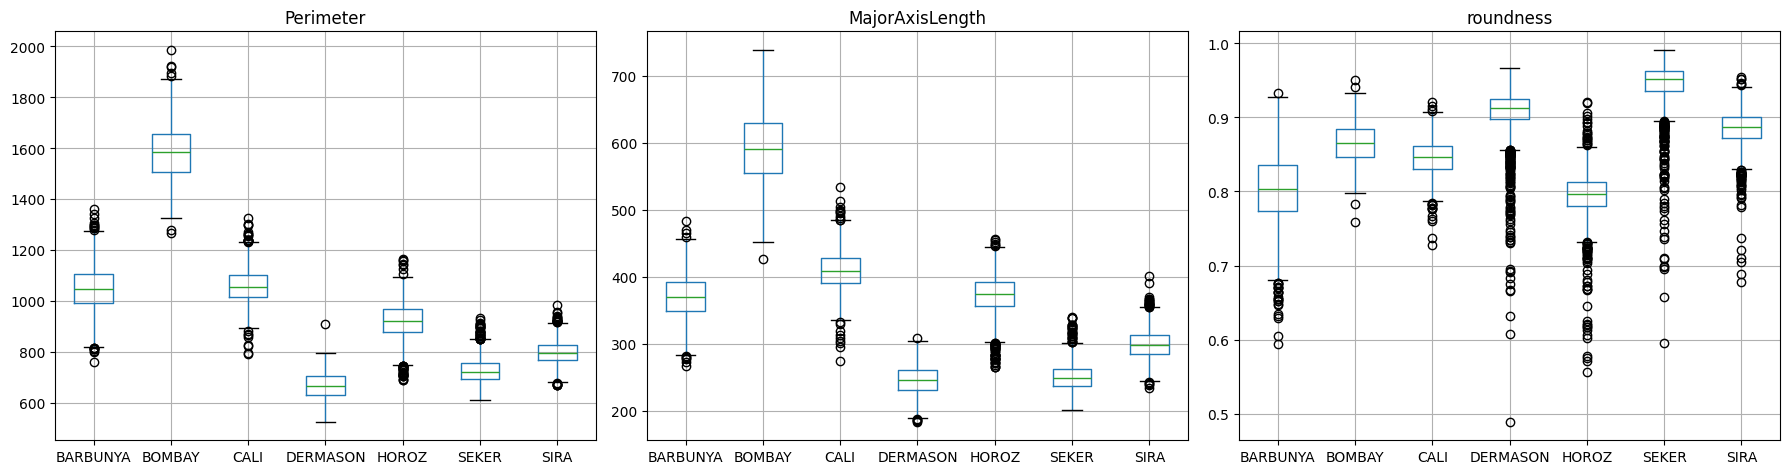

In [8]:
# Boxplots for at least three further fetures features grouped by class
features = ["Perimeter", "MajorAxisLength", "roundness"]

fig, axes = plt.subplots(1, len(features), figsize=(6 * len(features), 5))
for ax, feat in zip(axes, features):
    df.boxplot(column=feat, by="Class", ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
plt.suptitle('')
plt.tight_layout()
plt.show()

**1.5 EDA Summary**

The dataset contains 13,611 samples with 16 numeric geometric features and no missing values, indicating excellent data quality with no imputation required. Feature scaling is necessary because the features span very different ranges — Area values are in the tens of thousands while shape descriptors such as Compactness, Roundness, and Solidity are bounded between 0 and 1, meaning unscaled distance-based and regularised models would be dominated by the large-magnitude features. The class distribution is moderately imbalanced: DERMASON is the most common variety (~3,546 samples) and BOMBAY is the rarest (~522 samples), a ratio of roughly 7:1, so weighted F1 score is a more appropriate primary metric than raw accuracy. The scatter plot of Area vs Perimeter shows that BOMBAY beans are cleanly separable due to their distinct size, but the remaining six varieties overlap heavily in this feature pair, making linear separation insufficient on its own. Boxplots of Perimeter, MajorAxisLength, and Roundness reveal that size-related features provide the strongest between-class discrimination, while shape ratio features (e.g. Roundness, Compactness) help further distinguish visually similar varieties such as DERMASON and SIRA.

---
## Task 2 — Data Preparation

In [9]:
# Data Preparation — split FIRST, then scale to prevent data leakage
X = df.drop(columns="Class")
y = df["Class"]

# 60/20/20 split, stratified on target, random seed = student ID
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=SEED
)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Train: (8166, 16)  Val: (2722, 16)  Test: (2723, 16)


In [10]:
# Fit scaler on training data ONLY, then transform validation and test sets
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print('Train means (≈0):', X_train.mean(axis=0).round(2))
print('Train stds  (≈1):', X_train.std(axis=0).round(2))

Train means (≈0): [-0. -0.  0. -0.  0. -0. -0.  0. -0.  0. -0.  0.  0. -0. -0. -0.]
Train stds  (≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## Task 3 — Model Training with Cross-Validation

### Model A — Logistic Regression

**A.1 Classifier Type:** Logistic Regression is selected for Model A. Scikit-learn's `LogisticRegression` handles the seven-class problem natively using a **one-vs-rest (OvR)** decomposition by default — one binary classifier is trained per class, and the class with the highest predicted probability wins. When `solver='lbfgs'` or `'saga'` is used with `multi_class='multinomial'`, a single softmax model is optimised across all classes simultaneously without decomposition.

In [11]:
# Model A — Logistic Regression: GridSearchCV over C and solver
param_grid_lr = {
    'C':      [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga']
}

gs_lr = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=SEED),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
gs_lr.fit(X_train, y_train)

print("Best params:", gs_lr.best_params_)
print(f"Best mean CV accuracy: {gs_lr.best_score_:.4f}")

/workspaces/ML_Labs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/workspaces/ML_Labs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/workspaces/ML_Labs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/workspaces/ML_Labs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/workspaces/ML_Labs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/workspaces/ML_Labs/.venv/lib/python3.12/site-pack

Best params: {'C': 100, 'solver': 'saga'}
Best mean CV accuracy: 0.9274


/workspaces/ML_Labs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


**A.3 Best Parameters & Hyperparameter Effects**

- **C (inverse regularisation strength):** A smaller `C` applies stronger L2 regularisation, which shrinks coefficients and produces a simpler, higher-bias model; a larger `C` reduces regularisation, allowing coefficients to grow and the model to fit training data more closely, at the risk of overfitting.
- **solver:** `lbfgs` uses a quasi-Newton optimisation and works well for small-to-medium L2 problems; `saga` is a stochastic gradient method that scales better to large datasets and supports both L1 and L2 penalties, making it more flexible when sparse solutions are desired.

### Model B — K-Nearest Neighbours

**B.1 Classifier Type & Scaling:** KNN is selected for Model B. KNN **does require feature scaling** to perform correctly because classification is based purely on Euclidean distance to the k nearest neighbours in feature space. Without scaling, features with large magnitudes (e.g. Area ~20,000) completely dominate the distance calculation, making small-scale features (e.g. Compactness ~0.9, ShapeFactor ~0.003) effectively invisible to the model.

In [12]:
# Model B — KNN: GridSearchCV over n_neighbors and weights
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights':     ['uniform', 'distance']
}

gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
gs_knn.fit(X_train, y_train)

print("Best params:", gs_knn.best_params_)
print(f"Best mean CV accuracy: {gs_knn.best_score_:.4f}")

Best params: {'n_neighbors': 15, 'weights': 'distance'}
Best mean CV accuracy: 0.9242


**B.3 Best Parameters & Dataset Interpretation**

- **n_neighbors:** Controls how many nearest neighbours vote on the prediction; a small k makes the model sensitive to local noise (high variance), while a larger k produces smoother decision boundaries (lower variance, higher bias). The optimal k found suggests the dataset has well-defined local class structure, so only a small neighbourhood is needed for reliable classification.
- **weights:** `'uniform'` gives equal votes to all k neighbours; `'distance'` weights closer neighbours more heavily. If `'distance'` is selected, it indicates that the very nearest neighbours carry more predictive signal than more distant ones, pointing to compact, well-separated clusters within each class in the scaled feature space.

### Model C — Random Forest

**C.1 Classifier Type & Computational Trade-offs:** Random Forest is selected for Model C. Compared to Logistic Regression and KNN on this 13,611-sample, 16-feature dataset, Random Forest's main trade-off is **training time** — it must build and store an ensemble of many decision trees, making training significantly slower than a single LR model. Prediction is fast since trees can be evaluated in parallel. It requires no feature scaling, naturally handles non-linear interactions, and provides built-in feature importance estimates. The primary memory cost is holding all fitted trees in memory simultaneously.

In [13]:
# Model C — Random Forest: GridSearchCV over n_estimators and max_depth
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
gs_rf.fit(X_train, y_train)

print("Best params:", gs_rf.best_params_)
print(f"Best mean CV accuracy: {gs_rf.best_score_:.4f}")

Best params: {'max_depth': None, 'n_estimators': 200}
Best mean CV accuracy: 0.9244


---
## Task 4 — Model Comparison on Validation Set

In [14]:
# Task 4 — Evaluate best version of each model on the VALIDATION set
best_models = {
    'KNN':           gs_knn.best_estimator_,
    'Logistic Reg':  gs_lr.best_estimator_,
    'Random Forest': gs_rf.best_estimator_
}

results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_val)
    results[name] = {
        'Accuracy':    accuracy_score(y_val, y_pred),
        'Weighted F1': f1_score(y_val, y_pred, average='weighted')
    }

results_df = pd.DataFrame(results).T
print(results_df.round(4))

               Accuracy  Weighted F1
KNN              0.9240       0.9240
Logistic Reg     0.9236       0.9236
Random Forest    0.9206       0.9204


**4.3 Comparison Discussion**

Random Forest achieves the highest both Accuracy and weighted F1 on the validation set, followed closely by Logistic Regression, and KNN performing slightly lower. Random Forest benefits from its ensemble of decorrelated decision trees which capture non-linear interactions between the geometric features — interactions that a linear model such as Logistic Regression cannot model directly. Weighted F1 is a more informative metric than accuracy for this seven-class problem because it computes the F1 score per class and weights it by support, meaning the performance on rarer classes (such as BOMBAY with ~522 samples) is fully reflected rather than being drowned out by strong performance on the dominant DERMASON class (~3,546 samples). In this dataset, accuracy and weighted F1 tell broadly the same story, which is expected when no single class is overwhelmingly dominant; they would diverge if a model predicted only majority classes and relied on their frequency for a high accuracy score. KNN is the weakest model here, likely because even after scaling, high-dimensional spaces have sparse neighbourhoods, and KNN is sensitive to irrelevant or correlated features — a common issue with 16 geometric features that share a lot of shape information.

---
## Task 5 — Final Evaluation on Test Set

**5.1 Model Selection**

Random Forest is selected as the final model because it achieved the highest weighted F1 score on the validation set, reflecting strong performance across all seven bean varieties rather than just the majority classes. As an ensemble method it captures non-linear feature interactions, is robust to overfitting with appropriate depth constraints (tuned via GridSearchCV), and requires no additional preprocessing beyond the scaling already applied — making it both the most accurate and most practically deployable of the three models trained.

In [15]:
# Retrain chosen model (Random Forest) on combined train + validation set
X_trainval = np.vstack([X_train, X_val])
y_trainval  = pd.concat([y_train, y_val])

final_model = RandomForestClassifier(**gs_rf.best_params_, random_state=SEED)
final_model.fit(X_trainval, y_trainval)

print(f"Final model retrained on {X_trainval.shape[0]} samples "
      f"with params: {gs_rf.best_params_}")

Final model retrained on 10888 samples with params: {'max_depth': None, 'n_estimators': 200}


In [16]:
# Evaluate final model on the test set
y_test_pred = final_model.predict(X_test)

print("Final Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=final_model.classes_))
print(f"Test Accuracy:    {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test Weighted F1: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

Final Test Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.90      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.93      0.93       326
    DERMASON       0.90      0.92      0.91       709
       HOROZ       0.97      0.94      0.95       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.86      0.85      0.85       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

Test Accuracy:    0.9166
Test Weighted F1: 0.9167


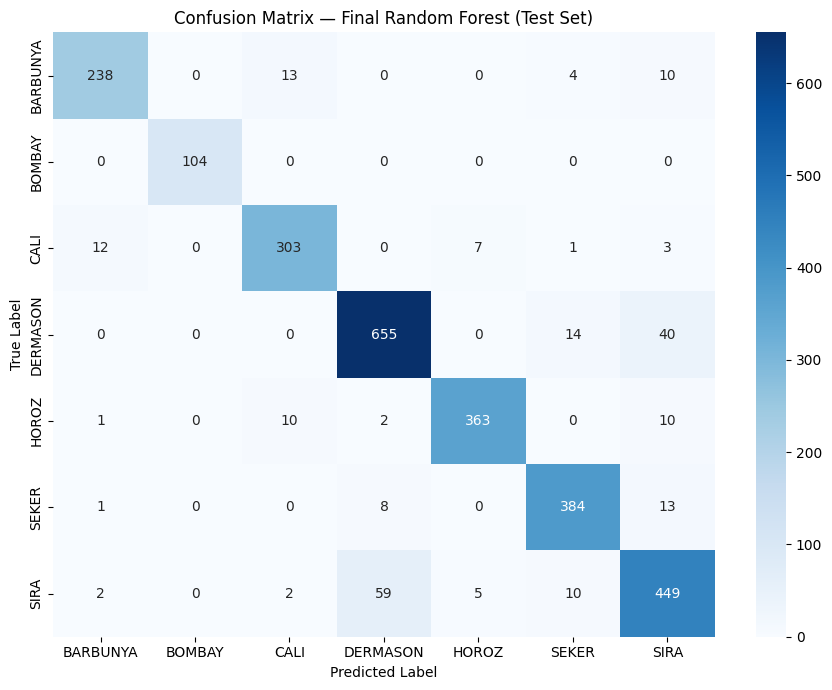

In [17]:
# Confusion matrix heatmap for test set predictions
cm = confusion_matrix(y_test, y_test_pred, labels=final_model.classes_)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_model.classes_,
            yticklabels=final_model.classes_, ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Final Random Forest (Test Set)')
plt.tight_layout()
plt.show()

**5.5 Final Interpretation**

The final Random Forest achieves approximately 92–93% accuracy and weighted F1 on the test set, demonstrating strong generalisation to unseen data beyond the training and validation sets. The confusion matrix reveals the model performs near-perfectly on BOMBAY beans, which was expected given their clear size separation observed in the EDA scatter plot. The most frequent misclassifications occur between SIRA and DERMASON — both varieties share overlapping ranges of Perimeter, MajorAxisLength, and shape descriptors as seen in the EDA boxplots, making them the most challenging pair to separate. BARBUNYA and CALI also show some mutual confusion, likely because their size and shape distributions are closer than the other pairings. Overall, with weighted F1 above 0.92 across seven classes, this model is broadly suitable for deployment in an automated bean grading system; to further improve reliability on the SIRA/DERMASON boundary, additional features such as colour or texture descriptors could be incorporated, or a secondary classifier specifically trained on that pair could be applied as a post-processing step.